I will be looking at SVR

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVR
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import RobustScaler

In [2]:
data = pd.read_csv("energydata_complete.csv")  
#pre processing

## this is converting the date to pure numerical values. regression models need this
data['date'] = pd.to_datetime(data['date'])

data['hour'] = data['date'].dt.hour
data['day_of_week'] = data['date'].dt.dayofweek

## drop unecessary data, rv1 and rv2 are declared as random variables in the dataset description
data = data.drop(columns=['date','rv1','rv2'])





Looking at any missing values (result: there are none)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 non-null  float64
 19  RH_9

Now lets run standard SVR with unmodified/basic hyperparameters. Also plotting results

MSE: 5171.495110227215
R2: 0.4832169447027779


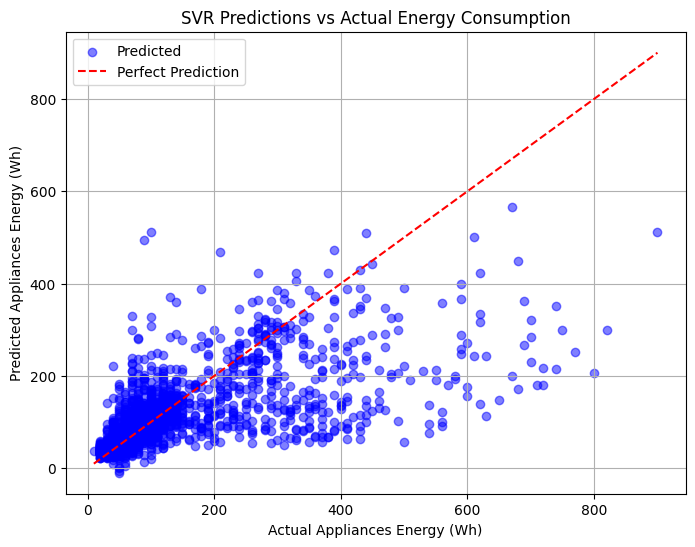

In [3]:
X = data.drop(columns=['Appliances']) #indepandant features
y = data['Appliances']  #target 
# test train split for the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Both target and independant features need to be scaled /n
# because if features and targets are on different scales, the optimization can be ill-conditioned.
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)


scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()


svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = svr.predict(X_test_scaled)
# Convert back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)
plt.figure(figsize=(8,6))

#plot results
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted')

#reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Appliances Energy (Wh)')
plt.ylabel('Predicted Appliances Energy (Wh)')
plt.title('SVR Predictions vs Actual Energy Consumption')
plt.legend()
plt.grid(True)
plt.show()




kernel svr is very slow with a dataset of this size, lets see results of linear SVR, maybe we can use that instead

c:\Users\mason\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


MSE: 9449.073073530657
R2: 0.05576226050973865


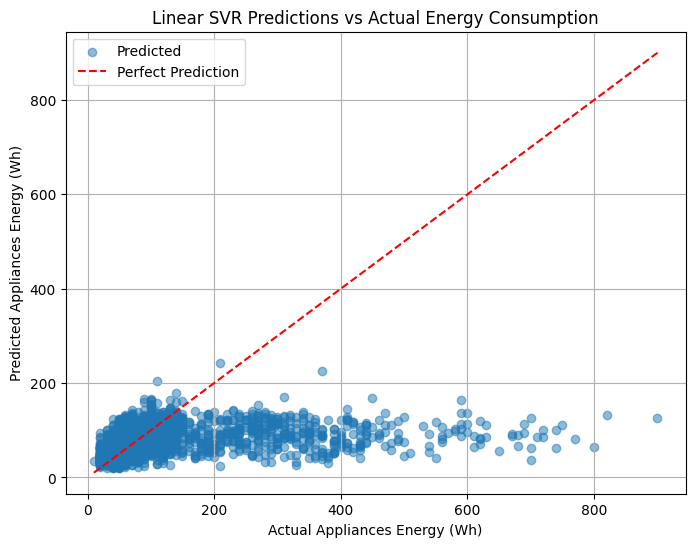

In [8]:

lsvr = LinearSVR(
    C=100,
    epsilon=0.1,
    max_iter=10000,
    random_state=42
)

lsvr.fit(X_train_scaled, y_train_scaled)


y_pred_scaled = lsvr.predict(X_test_scaled)


y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predicted')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Perfect Prediction'
)
plt.xlabel('Actual Appliances Energy (Wh)')
plt.ylabel('Predicted Appliances Energy (Wh)')
plt.title('Linear SVR Predictions vs Actual Energy Consumption')
plt.legend()
plt.grid(True)
plt.show()

Linear svr gave very bad r2 score, confirming that energy use prediction is highly non linear, lets try adding some non linearity before switching back to kernel svr

In [10]:
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('svr', LinearSVR(C=10, epsilon=0.1, max_iter=10000))
])

pipe.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = pipe.predict(X_test_scaled)

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()


r2 = r2_score(y_test, y_pred)

print("R2:", r2)

R2: 0.24069224330269978


c:\Users\mason\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.24 is better than just predicting the mean but its safe to say we need to switch back to kernel based svr

Now lets test some different hyperparameters using randomised search. Grid search is way too slow

In [ ]:



param_distributions = {
    'C': [10, 50, 100, 200, 500, 1000],       
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5, 1.0],  
    'gamma': ['scale', 0.001, 0.01, 0.05, 0.1, 0.5, 1]  
}

svr = SVR(kernel='rbf')

random_search = RandomizedSearchCV(
    svr,
    param_distributions=param_distributions,
    n_iter=30,    
    cv=3,            
    scoring='r2',
    n_jobs=-1,      
    verbose=2,
    random_state=42
)


X_train_scaled
y_train_scaled


random_search.fit(X_train_scaled, y_train_scaled)

best_svr = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'gamma': 0.5, 'epsilon': 0.1, 'C': 10}


Now we have some better parameters lets test the predictions again. Result: slight improvement in r2 score from 0.48 to 0.55

MSE: 4474.278481418382
R2: 0.552889202330423


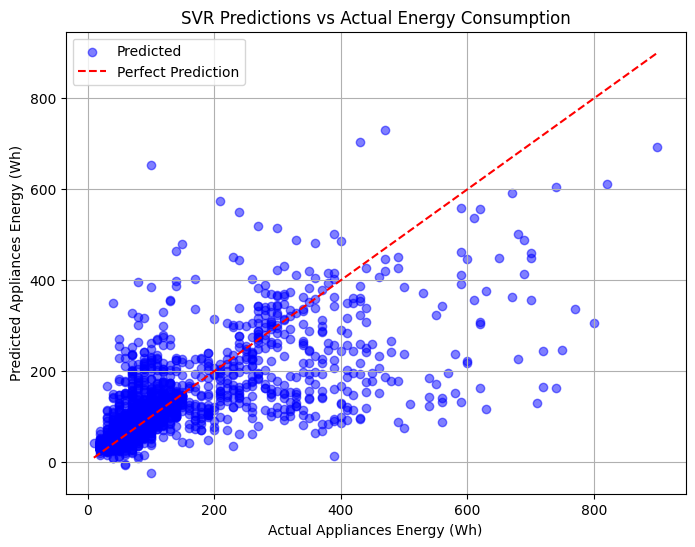

In [17]:



best_params = {'C': 10, 'epsilon': 0.1, 'gamma': 0.5}  

svr = SVR(kernel='rbf', **best_params)


svr.fit(X_train_scaled, y_train_scaled)


y_pred_scaled = svr.predict(X_test_scaled)


y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Appliances Energy (Wh)')
plt.ylabel('Predicted Appliances Energy (Wh)')
plt.title('SVR Predictions vs Actual Energy Consumption')
plt.legend()
plt.grid(True)
plt.show()


Lets check for over or underfitting, to see if hyperparams can be tuned even better

In [18]:

y_train_pred_scaled = svr.predict(X_train_scaled)
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()


mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("Training MSE:", mse_train)
print("Training R2:", r2_train)


Training MSE: 1560.14643472532
Training R2: 0.8533204595089495


We can see a such higher r2 on training set compared to test set. The model is overfitting

With that in mind, lets try randomised search again 

In [19]:
param_distributions = {
    'C': [50, 100, 200, 500, 1000, 2000],
    'epsilon': [0.1, 0.2, 0.3, 0.5],
    'gamma': ['scale', 0.01, 0.03, 0.05, 0.1, 0.2, 0.3]
}

svr = SVR(kernel='rbf')

random_search = RandomizedSearchCV(
    svr,
    param_distributions=param_distributions,
    n_iter=30,          
    cv=3,              
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)


random_search.fit(X_train_scaled, y_train_scaled)

best_svr = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'gamma': 0.05, 'epsilon': 0.1, 'C': 100}


lets try again

MSE: 4904.6222681352665
R2: 0.5098853181175351


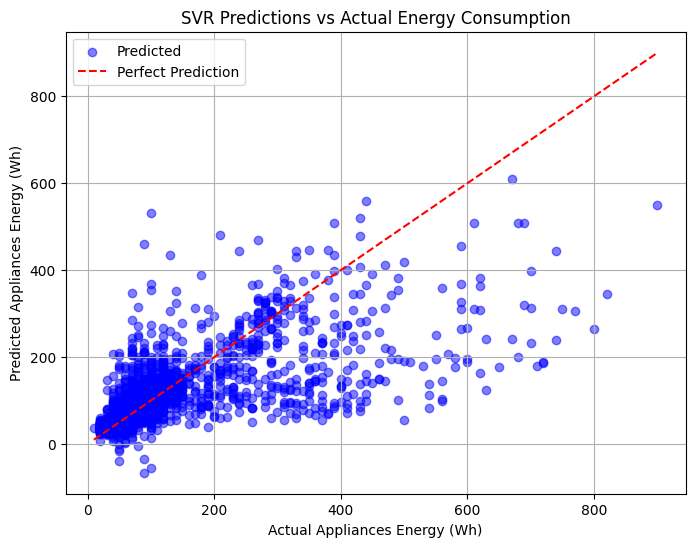

In [28]:


best_params = {'C': 100, 'epsilon': 0.1, 'gamma': 0.05}  

svr = SVR(kernel='rbf', **best_params)


svr.fit(X_train_scaled, y_train_scaled)


y_pred_scaled = svr.predict(X_test_scaled)


y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Appliances Energy (Wh)')
plt.ylabel('Predicted Appliances Energy (Wh)')
plt.title('SVR Predictions vs Actual Energy Consumption')
plt.legend()
plt.grid(True)
plt.show()

Lost some accuracy score, but model is no longer overfitting as much and will work better on truly unseen data

In [7]:
svr.fit(X_train_scaled, y_train_scaled)


y_pred_scaled = svr.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()


r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, scaler_y.inverse_transform(svr.predict(X_train_scaled).reshape(-1,1)).ravel())

print(f"Training R2: {r2_train:.3f}")
print(f"Test R2: {r2_test:.3f}")

Training R2: 0.687
Test R2: 0.510


Now lets try some feature selection 

In [38]:
feature_names = X_train.columns  

mi = mutual_info_regression(X_train_scaled, y_train_scaled)
mi_series = pd.Series(mi, index=feature_names).sort_values(ascending=False)

top_features = mi_series.tail(5).index
print("Bottom features from mutual info:", top_features)





Bottom features from mutual info: Index(['Press_mm_hg', 'RH_3', 'RH_8', 'RH_1', 'RH_4'], dtype='object')


MSE: 5544.365331775098
R2: 0.44595634439015375


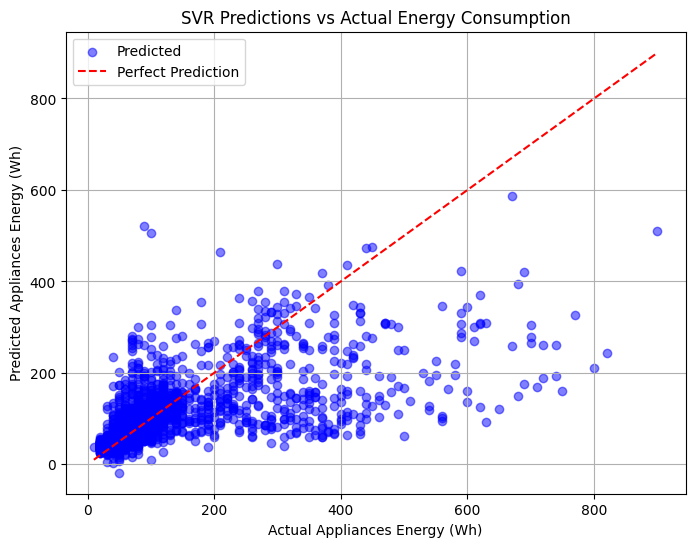

In [41]:
X = data.drop(columns=['Appliances', 'Press_mm_hg', 'RH_3', 'RH_8', 'RH_1', 'RH_4']) #indepandant features
y = data['Appliances']  #target 
# test train split for the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Both target and independant features need to be scaled /n
# because if features and targets are on different scales, the optimization can be ill-conditioned.
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)


scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()


svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = svr.predict(X_test_scaled)
# Convert back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)
plt.figure(figsize=(8,6))

#plot results
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted')

#reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Appliances Energy (Wh)')
plt.ylabel('Predicted Appliances Energy (Wh)')
plt.title('SVR Predictions vs Actual Energy Consumption')
plt.legend()
plt.grid(True)
plt.show()

Looking at permutations importance, we can see that all features have positive contribution to the accuracy

Permutation Importance (mean decrease in R²):
T3             3.765165
RH_2           1.302392
RH_3           1.229070
T_out          0.850841
RH_9           0.805697
RH_4           0.760969
RH_1           0.643066
T1             0.612050
T7             0.590596
Tdewpoint      0.558602
T4             0.529748
T8             0.507632
RH_6           0.438135
T5             0.436711
T6             0.423517
day_of_week    0.358836
T2             0.358409
RH_8           0.338875
T9             0.334478
RH_out         0.330430
RH_7           0.309484
Press_mm_hg    0.285632
RH_5           0.231094
Windspeed      0.218373
hour           0.191012
lights         0.122751
Visibility     0.112954
dtype: float64


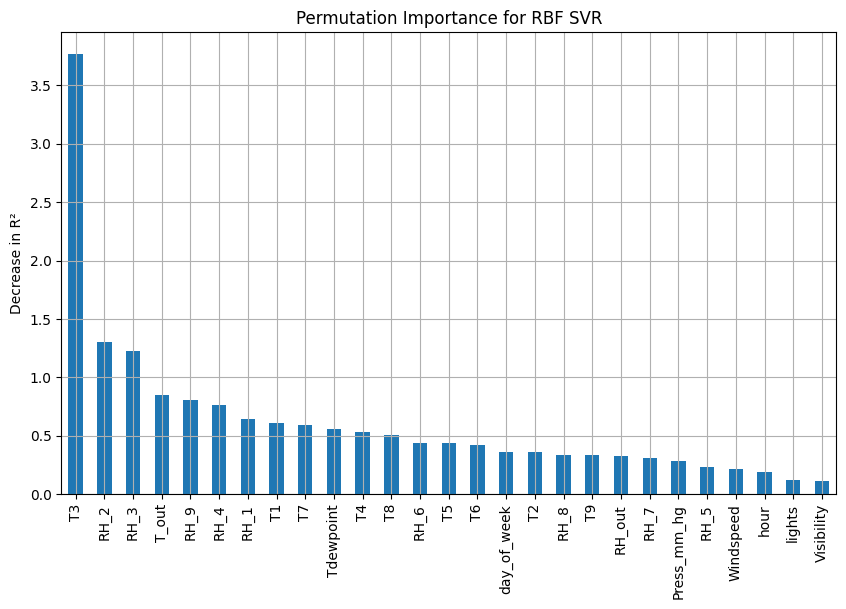


Features with zero or negative importance:
Index([], dtype='object')


In [4]:

perm = permutation_importance(
    svr,
    X_test_scaled,
    y_test_scaled,
    scoring='r2',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("Permutation Importance (mean decrease in R²):")
print(perm_importance)


plt.figure(figsize=(10, 6))
perm_importance.plot(kind='bar')
plt.ylabel('Decrease in R²')
plt.title('Permutation Importance for RBF SVR')
plt.grid(True)
plt.show()


weak_features = perm_importance[perm_importance <= 0].index
print("\nFeatures with zero or negative importance:")
print(weak_features)


Maybe we can transform some features, lets look at outliers using box plots

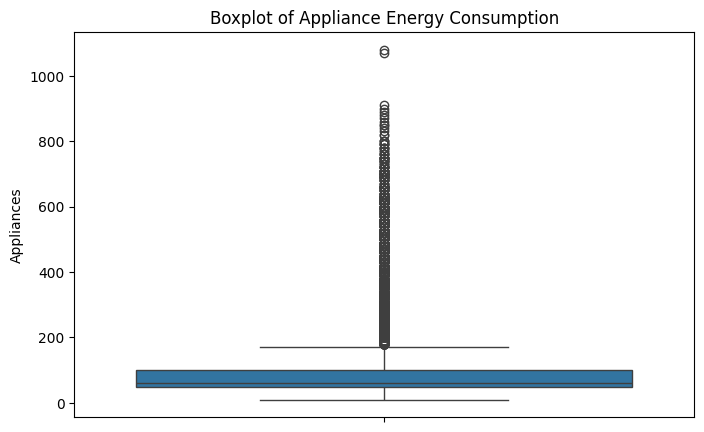

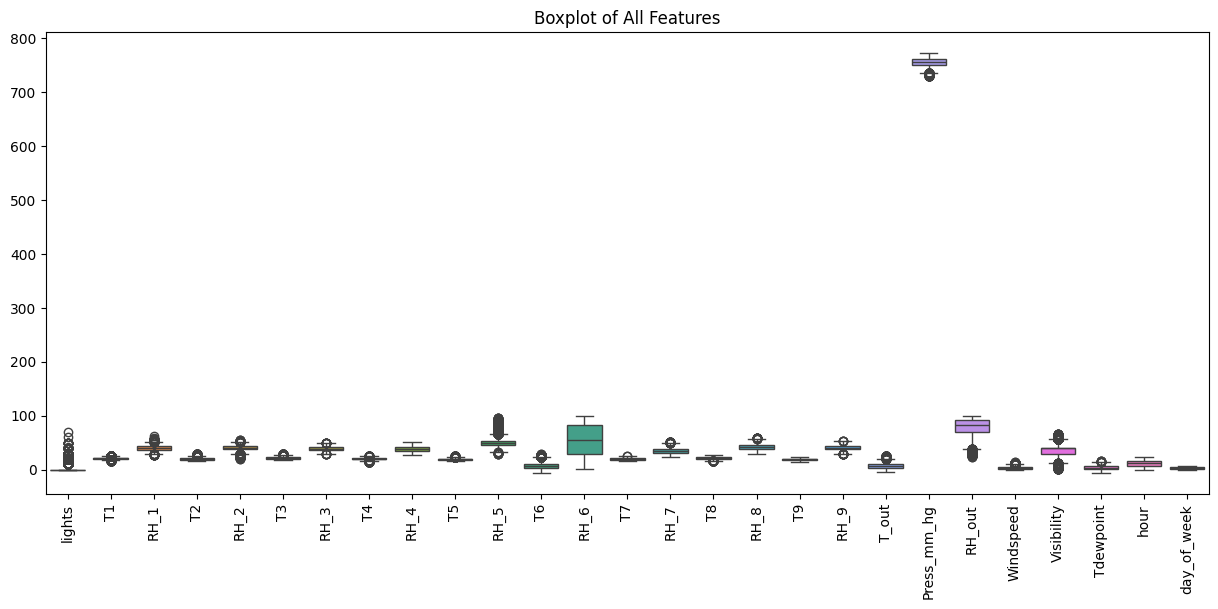

In [8]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(y=y)
plt.title('Boxplot of Appliance Energy Consumption')
plt.show()


plt.figure(figsize=(15, 6))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title('Boxplot of All Features')
plt.show()

We see lots of outliers with appliances, maybe log transfrom?